# Phase 7: Dimensionality Reduction & Clustering
## Project Pivot: Game-Centric Representation
This notebook implements the reduction of the Master Table features and the semantic embeddings to identify **Bridge Titles** using clustering techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
import os

# Settings
sns.set(style="whitegrid")
os.makedirs('../reports/figures', exist_ok=True)

c:\Users\SeuNg720\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Enriched Master Table & Embeddings

In [2]:
df = pd.read_parquet('../data/processed/master_games_ml_enriched.parquet')
embeddings = np.load('../data/processed/game_embeddings.npy')

print(f"Master Table Shape: {df.shape}")
print(f"Embeddings Shape: {embeddings.shape}")

Master Table Shape: (50872, 25)
Embeddings Shape: (50872, 384)


### 2. Feature Selection & Scaling
We select numerical metrics (hours, ratings, sentiment) and combine them with the semantic embeddings.

In [3]:
numerical_cols = [
    'hours_mean', 'hours_median', 'hours_std', 
    'rec_ratio', 'review_count', 'fan_avg_products', 
    'hater_avg_products', 'sentiment_score'
]

X_num = df[numerical_cols].values

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Combine with embeddings (we might want to weight them differently)
# For now, we concatenate them
X_combined = np.hstack([X_num_scaled, embeddings])

print(f"Combined Feature Matrix Shape: {X_combined.shape}")

Combined Feature Matrix Shape: (50872, 392)


### 3. PCA: Dimensionality Reduction & Justification
The professor requested a justification for the number of components.

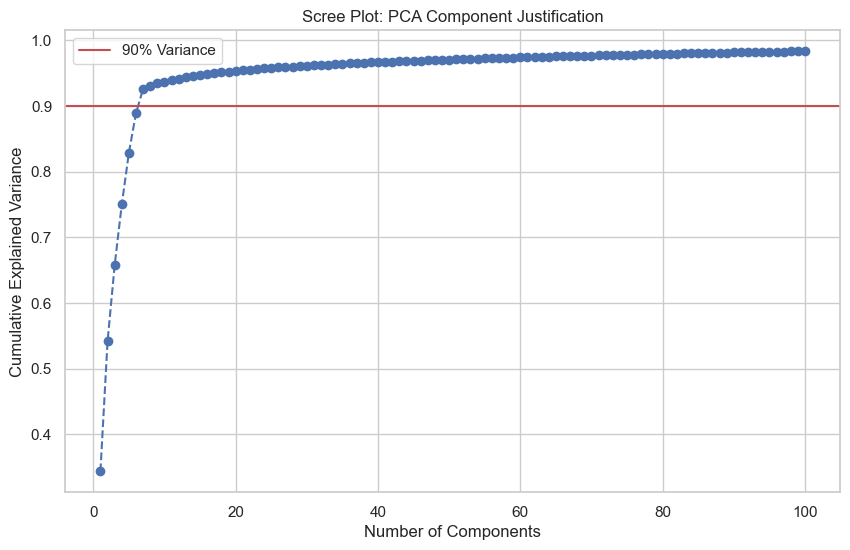

Number of components to explain 90% variance: 7


In [4]:
pca = PCA(n_components=100) # Analyze first 100 components
pca.fit(X_combined)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: PCA Component Justification')
plt.legend()
plt.savefig('../reports/figures/pca_justification.png')
plt.show()

n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components to explain 90% variance: {n_comp_90}")

### 4. Clustering (K-Means)
We use the reduced PCA space for stable clustering.

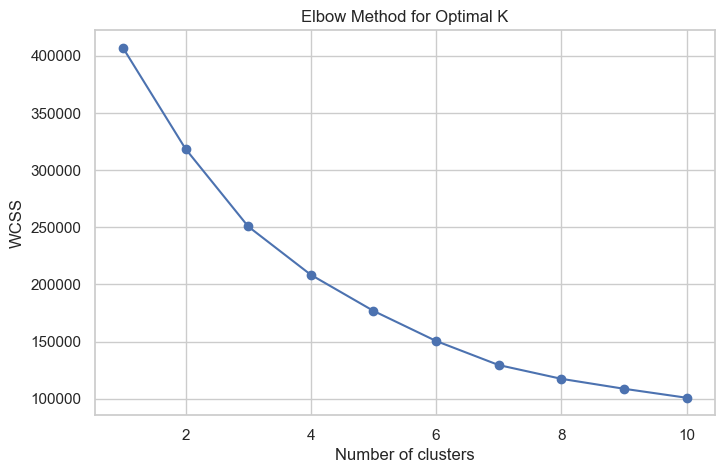

In [5]:
# Reducing to the optimized number of components
X_pca = PCA(n_components=n_comp_90).fit_transform(X_combined)

# Finding optimal K (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig('../reports/figures/kmeans_elbow.png')
plt.show()

### 5. Final Visualization with UMAP
We assign clusters and project into 2D.

C:\Users\SeuNg720\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\SeuNg720\AppData\Roaming\Python\Python314\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\SeuNg720\AppData\Roaming\Python\Python314\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\SeuNg720\AppData\Roaming\Python\Python314\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small 

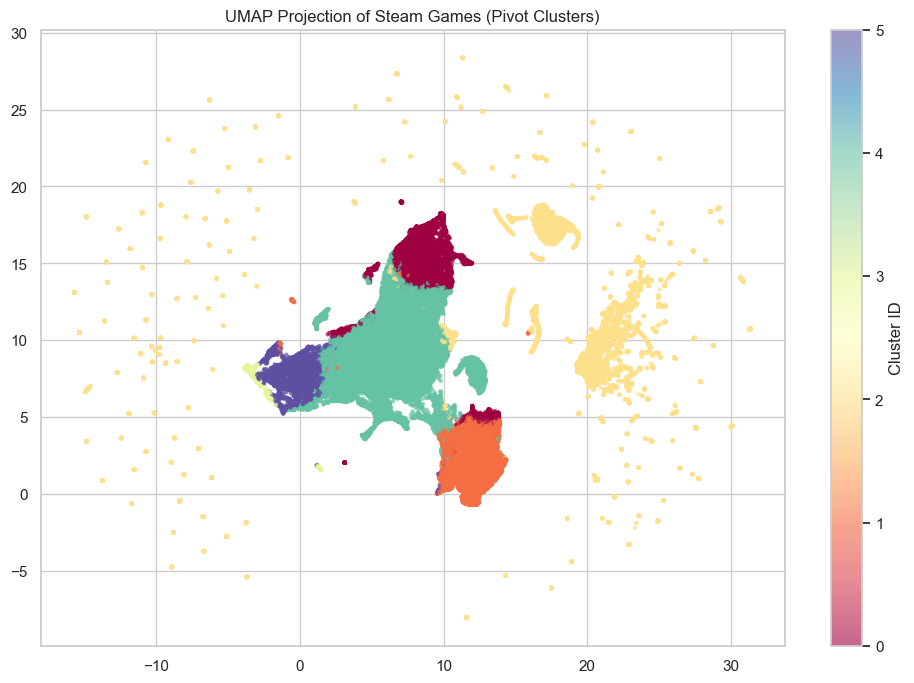

In [8]:
# Assuming k=6 based on elbow (adjust after running)
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca)

# UMAP for 2D visualization
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(X_pca)

df['umap_x'] = embedding_2d[:, 0]
df['umap_y'] = embedding_2d[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['umap_x'], df['umap_y'], c=df['cluster'], cmap='Spectral', s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('UMAP Projection of Steam Games (Pivot Clusters)')
plt.savefig('../reports/figures/umap_pivot_clusters.png')
plt.show()

### 6. Identifying Bridge Titles
Games with high proximity to multiple cluster centroids.

In [9]:


# Sample bridge analysis: games in cluster boundaries
df[['app_id', 'title', 'cluster', 'umap_x', 'umap_y']].head(10)

,app_id,title,cluster,umap_x,umap_y
0,13500,Prince of Persia: Warrior Within™,4,3.648470,7.056246
1,22364,BRINK: Agents of Change,2,-10.721869,2.779136
2,113020,Monaco: What's Yours Is Mine,4,3.069183,6.497675
3,226560,Escape Dead Island,4,6.172118,9.472641
4,249050,Dungeon of the ENDLESS™,4,1.445242,6.636692
5,250180,METAL SLUG 3,4,4.600801,6.820268
6,253980,Enclave,4,4.968792,7.483355
7,271850,Men of War: Assault Squad 2 - Deluxe Edition u...,2,23.363279,13.409408
8,282900,Hyperdimension Neptunia Re;Birth1,5,0.489405,6.699372
9,19810,The Sum of All Fears,4,3.975041,8.532011


In [10]:
df['cluster'].value_counts()

cluster
4    21351
2    13924
1     7191
0     4938
5     3113
3      355
Name: count, dtype: int64

In [11]:
# Interpretation of the 7 components
feature_names = numerical_cols + [f'embed_{i}' for i in range(384)]
loadings = pd.DataFrame(
    pca.components_[:7].T, 
    columns=[f'PC{i+1}' for i in range(7)],
    index=feature_names
)

print("Top Features per Principal Component (Numerical Only for clarity):")
for pc in loadings.columns:
    print(f"\n{pc} top numerical contributors:")
    print(loadings.loc[numerical_cols, pc].sort_values(ascending=False).head(3))

# Adding the 7 components to the dataset for final modeling
pca_final = PCA(n_components=7)
X_pca_final = pca_final.fit_transform(X_combined)

for i in range(7):
    df[f'pca_component_{i+1}'] = X_pca_final[:, i]

print(f"\nSuccessfully integrated 7 PCA components. New dataframe columns: {[col for col in df.columns if 'pca' in col]}")


Top Features per Principal Component (Numerical Only for clarity):

PC1 top numerical contributors:
hours_mean      0.560516
hours_median    0.518308
hours_std       0.510863
Name: PC1, dtype: float64

PC2 top numerical contributors:
fan_avg_products      0.632735
hater_avg_products    0.569621
rec_ratio             0.486690
Name: PC2, dtype: float64

PC3 top numerical contributors:
sentiment_score    0.989433
hours_std          0.015191
hours_mean         0.002990
Name: PC3, dtype: float64

PC4 top numerical contributors:
review_count          0.901096
hater_avg_products    0.168422
sentiment_score       0.116228
Name: PC4, dtype: float64

PC5 top numerical contributors:
hater_avg_products    0.726957
hours_mean            0.134242
hours_std             0.129882
Name: PC5, dtype: float64

PC6 top numerical contributors:
fan_avg_products    0.740405
hours_median        0.177975
hours_mean          0.108940
Name: PC6, dtype: float64

PC7 top numerical contributors:
hours_median         

In [12]:
# Save final result with clusters
df.to_parquet('../data/processed/master_games_clustered.parquet', index=False)
#print("Clustered data saved to: ../data/processed/master_games_clustered.parquet")